# Student Placement Classification Analysis

In [40]:
print("=" * 60)
print("Student Placement Classification ")
print("=" * 60)

Student Placement Classification 


# Import Libraries

Need several libraries, as a different one is needed for each model type that is looked at

In [42]:
print("=" * 60)
print("Import Libraries ")
print("=" * 60)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm
from ISLP.models import (ModelSpec as MS, summarize, poly)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.svm import SVC
import os

print("All Libraries Loaded")

Import Libraries 
All Libraries Loaded


# Exploratory Data Analysis

Exploration of the data to ensure understanding and allow for better analysis moving forward

>**Key Takeaways:** The only null values are in `company_type` and `job_role`, which won't cause any issues with the classification analysis that is being completed. There aren't any duplicate entries that need to be fixed. 

In [43]:
df = pd.read_csv('student_placement_salary_elite_v2.csv')

print("=" * 60)
print("DataSet Overview")
print("=" * 60)
print(f"\nDataset Shape:\n\n {df.shape}") 
print(f"\nColumn Names:\n\n {list(df.columns)}") 
print(f"\nFirst 5 Rows:\n") # Gives a general idea of what the dataset looks like
print(df.head()) 
print(f"\nNull Values\n")
print(pd.isnull(df).sum()) #Ensure no missing values
print(f"\nFeature Data Types\n")
print(df.dtypes) # Will need this when doing other coding
print(f"\nDuplicated Entries\n")
print(df.duplicated().sum()) # Ensure no duplicated entries that could skew the data analysis

DataSet Overview

Dataset Shape:

 (9000, 20)

Column Names:

 ['student_id', 'cgpa', 'branch', 'college_tier', 'python_skill', 'dsa_skill', 'ml_skill', 'web_dev_skill', 'coding_score', 'communication_score', 'aptitude_score', 'internships', 'projects', 'backlogs', 'resume_score', 'skill_score', 'placed', 'company_type', 'job_role', 'salary_lpa']

First 5 Rows:

  student_id  cgpa      branch  college_tier  python_skill  dsa_skill  \
0         S0  6.87       Civil             1             1          1   
1         S1  6.52       Civil             2             1          0   
2         S2  5.33          IT             1             1          1   
3         S3  6.04       Civil             3             1          0   
4         S4  6.78  Mechanical             2             0          1   

   ml_skill  web_dev_skill  coding_score  communication_score  aptitude_score  \
0         0              0          15.6                  4.3            92.0   
1         0              1        

# Descriptive Statistics of the Features

This gives insight as to the average, minimum, and maximum of each feature, while also showing how many unique responses for each feature as well as other potential insights. 

>**Key Takeaways:** These statistics were turned into a heatmap to better see extreme highs and lows for certain measures

In [4]:
print("=" * 60)
print("DataSet Overview: Descriptive Statistics")
print("=" * 60)

print(f"\nSummary Statistics:")

df.describe(include='all').T.style.background_gradient(cmap='Greens', subset=['mean', 'std', '50%']) #Conversion to a heatmap

DataSet Overview: Descriptive Statistics

Summary Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,9000,9000,S0,1,nan,nan,nan,nan,nan,nan,nan
cgpa,9000.000000,nan,nan,nan,7.507213,1.446496,5.000000,6.257500,7.500000,8.750000,10.000000
branch,9000,6,IT,1564,nan,nan,nan,nan,nan,nan,nan
college_tier,9000.000000,nan,nan,nan,2.011778,0.818224,1.000000,1.000000,2.000000,3.000000,3.000000
python_skill,9000.000000,nan,nan,nan,0.650111,0.476961,0.000000,0.000000,1.000000,1.000000,1.000000
dsa_skill,9000.000000,nan,nan,nan,0.555556,0.496932,0.000000,0.000000,1.000000,1.000000,1.000000
ml_skill,9000.000000,nan,nan,nan,0.299778,0.458186,0.000000,0.000000,0.000000,1.000000,1.000000
web_dev_skill,9000.000000,nan,nan,nan,0.393444,0.488541,0.000000,0.000000,0.000000,1.000000,1.000000
coding_score,9000.000000,nan,nan,nan,49.783567,28.891340,0.000000,24.900000,49.600000,74.625000,100.000000
communication_score,9000.000000,nan,nan,nan,6.991267,1.717548,4.000000,5.500000,7.000000,8.500000,10.000000


# Graphical Representation of the Data

These graphs give further understanding of the data and allows visualization to see it in a different way.


Exploratory Data Visualizations


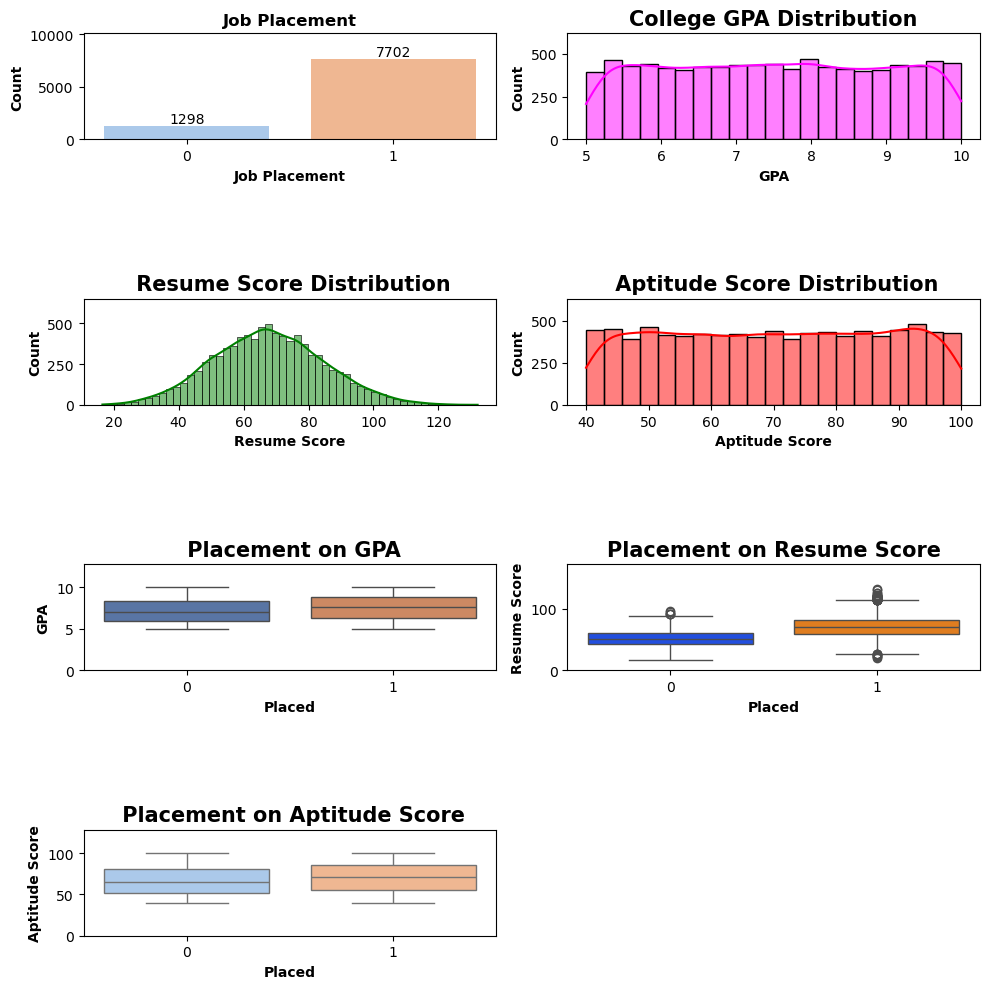

In [46]:
print("=" * 60)
print("Exploratory Data Visualizations")
print("=" * 60)

fig, axes = plt.subplots(4, 2, figsize=(10,10))
axes = axes.flatten() # Turns a 2D array into a 1D list, makes plotting loops much easier

sns.countplot(data=df, x="placed", palette="pastel", ax=axes[0], legend=True)  
axes[0].set_xlabel("Job Placement", fontweight = 'bold') 
axes[0].set_ylabel("Count", fontweight = 'bold')
axes[0].set_title("Job Placement", fontweight='bold')

sns.histplot(data=df, x='cgpa', color='magenta', ax=axes[1], kde=True)
axes[1].set_title('College GPA Distribution', fontsize=15, fontweight='bold')
axes[1].set_xlabel('GPA', fontweight='bold')
axes[1].set_ylabel('Count', fontweight='bold')

sns.histplot(data=df, x='resume_score', color='green', ax=axes[2], kde=True)
axes[2].set_title(' Resume Score Distribution', fontsize=15, fontweight='bold')
axes[2].set_xlabel('Resume Score', fontweight='bold')
axes[2].set_ylabel('Count', fontweight='bold')

sns.histplot(data=df, x='aptitude_score', color='red', ax=axes[3], kde=True)
axes[3].set_title(' Aptitude Score Distribution', fontsize=15, fontweight='bold')
axes[3].set_xlabel('Aptitude Score', fontweight='bold')
axes[3].set_ylabel('Count', fontweight='bold')

sns.boxplot(data=df, x='placed', y='cgpa', palette = 'deep', ax=axes[4])
axes[4].set_title(' Placement on GPA', fontsize=15, fontweight='bold')
axes[4].set_xlabel('Placed', fontweight='bold')
axes[4].set_ylabel('GPA', fontweight='bold')

sns.boxplot(data=df, x='placed', y='resume_score', palette = 'bright', ax=axes[5])
axes[5].set_title('Placement on Resume Score', fontsize=15, fontweight='bold')
axes[5].set_xlabel('Placed', fontweight='bold')
axes[5].set_ylabel('Resume Score', fontweight='bold')

sns.boxplot(data=df, x='placed', y='aptitude_score', palette = 'pastel', ax=axes[6])
axes[6].set_title(' Placement on Aptitude Score', fontsize=15, fontweight='bold')
axes[6].set_xlabel('Placed', fontweight='bold')
axes[6].set_ylabel('Aptitude Score', fontweight='bold')

for p in axes[0].patches: # Adds totals to top of the first countplot
    height = int(p.get_height())
    axes[0].annotate(
        f'{height}',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom'
    )

for ax in axes: # Adds more room in the graph 
    ymax = ax.get_ylim()[1]
    ax.set_ylim(0, ymax * 1.25)  

fig.delaxes(axes[7]) #Delete the last plot because it wasn't used
plt.tight_layout()
plt.subplots_adjust(hspace=1.5) # Increases spacing between graphs to prevent overlapping
plt.show()


# Creation of Correlation Matrix and Heatmap

This lays out how correlated variables are to each other and the predicted variable `placed`.

>**Key Takeaways:** We see low correlation for most of the features to `placed` with the exception of `salary_lpa`, which won't take a roll in the analysis since it is related to those that had job placement. The next strongest correlation score for `placed` is with the feature `resume_score` with a correlation of 0.39

Correlation Matrix and Heatmap
                         cgpa  college_tier  python_skill  dsa_skill  \
cgpa                 1.000000      0.000108     -0.008449   0.001222   
college_tier         0.000108      1.000000      0.004296  -0.004069   
python_skill        -0.008449      0.004296      1.000000  -0.020889   
dsa_skill            0.001222     -0.004069     -0.020889   1.000000   
ml_skill            -0.003027      0.008662     -0.007627  -0.013123   
web_dev_skill        0.000701     -0.000474      0.003318  -0.001475   
coding_score         0.003648     -0.005037     -0.010996  -0.014913   
communication_score  0.006023     -0.015204      0.004395   0.009201   
aptitude_score      -0.011885     -0.006763      0.010485  -0.022263   
internships         -0.005721      0.006130     -0.010907  -0.008563   
projects             0.008058     -0.006845     -0.002695   0.011684   
backlogs            -0.014016     -0.004119      0.003673  -0.006185   
resume_score         0.001840    

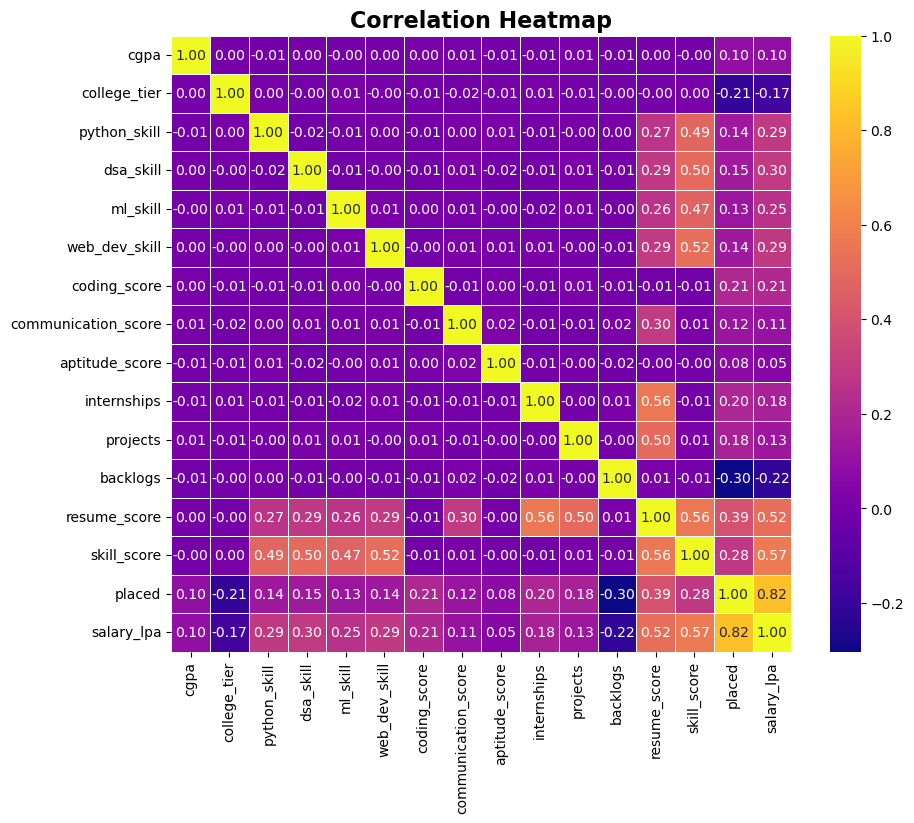

In [47]:
print("=" * 60)
print("Correlation Matrix and Heatmap")
print("=" * 60)


numeric_df = df.select_dtypes(include=[np.number]) # Only use numeric features 
corr_numeric = numeric_df.corr() 
print(corr_numeric) # Printing the correlation matrix

plt.figure(figsize=(10, 8))

sns.heatmap( # Convert the correlation matrix into a heatmap
    corr_numeric,
    annot=True,     
    fmt = '.2f', # Only go to 3 decimal places
    cmap='plasma',   
    linewidths=0.5     
)

plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

# Building Features 

These will be used as the building blocks for different models that are looked at. Some models will need the data to be scaled, while others won't hence we have 2 different test and train sets for X. 

In [15]:
print("=" * 60)
print("Building Features")
print("=" * 60)

X = df.drop(columns=['student_id','salary_lpa','placed', 'company_type', 'job_role', 'branch']) #Drop the unrelated columns
y = df["placed"] # Feature that is being predicted

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42)

scaler = StandardScaler() # Convert to Mean 0 and Standard Deviation 1 for all data points (only necessary for some models)
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.fit_transform(X_test)

print("Training set size:", X_train.shape[0], "observations")
print("Testing set size: ", X_test.shape[0], "observations")

Building Features
Training set size: 6300 observations
Testing set size:  2700 observations


# No Model Accuracy

An accuracy of 84% is established if no model is used and everyone is classified as being placed in a job. This gives us a baseline to compare other models to. 

In [17]:
print("=" * 60)
print("No Model Accuracy")
print("=" * 60)

print(y_test.value_counts())

print(f"Accuracy if Predict All Students Get A Job Placement. {2280/2700:.2f}") #Gives us a baseline to compare other models to

No Model Accuracy
placed
1    2280
0     420
Name: count, dtype: int64
Accuracy if Predict All Students Get A Job Placement. 0.84


# Logistic Regression Model

Creation of logistic regression model that uses a weighted sum of inputs to establish a probability that each data point will be classified as 0 or 1.

>**Key Takeaways:** This model gives an accuracy of 92% 

In [48]:
print("\n" + "="*50)
print("LOGISTIC REGRESSION")
print("="*50)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Accuracy:     ", round(accuracy_score(y_test, lr_pred), 4)) #Gives a number to compare other models to based on the test set
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))


LOGISTIC REGRESSION
Accuracy:      0.92

Confusion Matrix:
[[ 266  154]
 [  62 2218]]


# Decision Tree Model

Creation of a Decision Tree Model that uses a set of if then rules to classify data. This often works like a flow chart and looks like an upside down tree when visualized.

>**Key Takeaways:** This model gives an accuracy of 88.33% 

In [56]:
print("\n" + "="*50)
print("Decision Tree")
print("="*50)

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42) # Allows for 4 splits
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)



Decision Tree

Accuracy: 0.8833

Confusion Matrix:
[[ 149  271]
 [  44 2236]]


# Naive Bayes Model

This creates a Naive Bayes Model which uses probability and the Bayes' Theorem to make classifications.

>**Key Takeaways:** This model gives an accuracy of 89.74% 

In [24]:
print("\n" + "="*50)
print("Naive Bayes")
print("="*50)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

print("Accuracy:     ", round(accuracy_score(y_test, nb_pred), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, nb_pred))


Naive Bayes
Accuracy:      0.8974

Confusion Matrix:
[[ 296  124]
 [ 153 2127]]


# K-Nearest Neighbors Model

This model uses the closest points to the new data for classification based on similarity.

>**Key Takeaways:** This model gives an accuracy of 86.11% 

In [57]:
print("\n" + "="*50)
print("K-Nearest Neighbors")
print("="*50)

knn_model = KNeighborsClassifier(n_neighbors=3) # Uses 3 nearest neighbors for classification
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)

print("Accuracy:     ", round(accuracy_score(y_test, knn_pred), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, knn_pred))



K-Nearest Neighbors
Accuracy:      0.8611

Confusion Matrix:
[[ 151  269]
 [ 106 2174]]


# Support Vector Machine Model With a Linear Kernel

This model uses a linear boundary to maximize the margin between classes.

>**Key Takeaways:** This model gives an accuracy of 92.07% 

In [58]:
svm_linear = SVC(kernel='linear', C=1.0, random_state=42) # C controls the tradeoff between the width of the margin and allowable misclassifications
svm_linear.fit(X_train_scaled, y_train)
pred_linear = svm_linear.predict(X_test_scaled)

print("\n" + "=" * 60)
print("SECTION 3: LINEAR KERNEL SVM  (C = 1.0)")
print("=" * 60)
print(f"Accuracy: {round(accuracy_score(y_test, pred_linear), 4)}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_linear))



SECTION 3: LINEAR KERNEL SVM  (C = 1.0)
Accuracy: 0.9207

Confusion Matrix:
[[ 264  156]
 [  58 2222]]


# Support Vector Machine Model With a Radial Kernel

This model uses a radial or non-linear kernel to find a boundary to maximize margin between classes to make classifications.

>**Key Takeaways:** This model gives an accuracy of 91.07% 

In [59]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42) # Gamma controls the influence of each data point
svm_rbf.fit(X_train_scaled, y_train)
pred_rbf = svm_rbf.predict(X_test_scaled)

print("\n" + "=" * 60)
print("SECTION 4: RBF KERNEL SVM  (C = 1.0, gamma = scale)")
print("=" * 60)
print(f"Accuracy: {round(accuracy_score(y_test, pred_rbf), 4)}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, pred_rbf))


SECTION 4: RBF KERNEL SVM  (C = 1.0, gamma = scale)
Accuracy: 0.9107

Confusion Matrix:
[[ 240  180]
 [  61 2219]]


# Model Accuracy Comparison

This compares the accuracy scores of the different models looked at. 

>**Key Takeaways:** The highest accuracy score was from the Support Vector Machine Model with the Linear Kernel at 92.07% Accuracy. 

In [60]:
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
print(f"  No Model Accuracy (Predict all 0)     {1354/2000}")
print(f"  Logistic Regression Accuracy:         {round(accuracy_score(y_test, lr_pred), 4)}")
print(f"  Naive Bayes Accuracy:                 {round(accuracy_score(y_test, nb_pred), 4)}")
print(f"  KNN Accuracy:                         {round(accuracy_score(y_test, knn_pred), 4)}")
print(f"  SVM Linear Accuracy:                  {round(accuracy_score(y_test, pred_linear), 4)}")
print(f"  SVM RBF Accuracy:                     {round(accuracy_score(y_test, pred_rbf), 4)}")
print(f"  Decision Tree Accuracy:               {round(accuracy_score(y_test, y_pred), 4)}")


MODEL COMPARISON SUMMARY
  No Model Accuracy (Predict all 0)     0.677
  Logistic Regression Accuracy:         0.92
  Naive Bayes Accuracy:                 0.8974
  KNN Accuracy:                         0.8611
  SVM Linear Accuracy:                  0.9207
  SVM RBF Accuracy:                     0.9107
  Decision Tree Accuracy:               0.8833
